# Game Theory on Complex Networks
Playground to figure out network generation, update rules and simulations.

In [1]:
import networkx as nx 
import numpy as np
import random
import matplotlib.pyplot as plt
from tqdm.auto import tqdm 

np.random.seed(13)

### 1. Network Generation
Let's try to implement the network generation as described by [Gómez-Gardeñes et al., 2006](http://dx.doi.org/10.1103/PhysRevE.73.056124)

In [2]:
def generate_mixed_network(N:int=1000, alpha:float=0.0, m:int=4, m0_frac:float=0.1) -> nx.Graph:
    """Generates network according to mixed model by Gómez-Gardeñes and Moreno (2006),
    which interpolates between ER and BA model through the heterogeneity parameter alpha.

    Args:
        N (int, optional): Number of nodes. Defaults to 1000.
        alpha (float, optional): Heterogeneity parameter, can have values from 0 (BA-graph) 
            to 1 (ER-graph). Defaults to 0.0.
        m (int, optional): Number of edges added at each growth step. Defaults to 6.
        m0_frac (float, optional): Fraction of total nodes to form the initial fully connected
            graph before the growing process. Defaults to 0.1.

    Returns:
        nx.Graph: Output networkx graph.
    """
    m0 = int(N*m0_frac)
    G = nx.complete_graph(m0)  # initialise fully connected network with m0 nodes
    U_idx = np.arange(m0, N) # indices of N-m0 initially unconnected nodes
    G.add_nodes_from(U_idx)  # add the N-m0 unconnected nodes

    # we'll have to go through all N-m0 unconnected nodes, each selected randomly
    # let's do this by shuffeling the index list and go through the nodes in the
    # obtained random order
    np.random.shuffle(U_idx)

    for idx in U_idx:
        # create m links:
        for _ in range(m):
            # (re)compute node probs:
            E = G.number_of_edges() # TODO: catch cases with no initial edges etc!
            # with probability alpha select a uniformly random one of all nods
            # with probability 1-alpha select node via preferential attachment
            probs = np.array([(1.0-alpha)*val/(2*E - G.degree(idx)) + alpha*1/(N-1) for (node, val) in G.degree() if node != idx])
            #print(probs.sum())
            #print(probs.shape)
            node = np.random.choice(np.delete(np.arange(N), idx), p=probs)
            G.add_edge(idx, node)

    return G

50
163


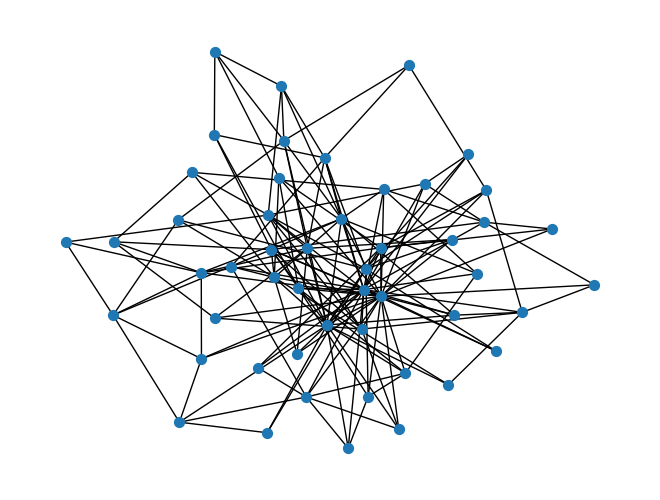

In [3]:
G = generate_mixed_network(N=50)
print(G.number_of_nodes())
print(G.number_of_edges())
nx.draw(G, node_size=50)

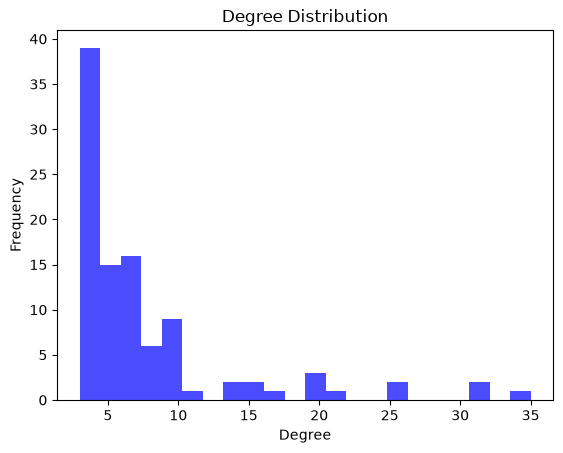

In [4]:
# plot degree distribution
G = generate_mixed_network(N=100)
degree_sequence = sorted([d for n, d in G.degree()], reverse=True) 
plt.hist(degree_sequence, bins=22, color='blue', alpha=0.7)
plt.title("Degree Distribution")    
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.show()

### Running the Ultimatum game
Time to figure this out!
- Each node has a strategy (p, q) -> add strategy as node attribute
- Figure out how to run 1 time step where each node plays with each of its neighbors and accumulates payoff -> also track payoff as node attribute?
- first initialize, then play!
- each node has an update rule (MOR, REP, UI, ...) to be added as node attribute (but that's for later)

Defining the update rules:

In [79]:
def MOR_update(G: nx.Graph, node, nbs, payoffs, strategies, update_rules, degrees):
    neighbors = nbs.copy()
    neighbors.append(node)
    # build payoff array
    nb_payoffs = payoffs[neighbors]
    total = nb_payoffs.sum()
    # if no payoff has been obtained, just keep the current strategy for now
    # to avoid division by zero
    # TODO: REPLACE WITH UNIFORMLY RANDOM CHOICE, WHICH MAKES MORE SENSE (I think)
    if total <= 0: # so if no payoff has been obtained at all
        return strategies[node], update_rules[node]
    # choose neighbor with probability proportional to payoff
    nb_chosen = np.random.choice(neighbors, p=nb_payoffs/total)
    return strategies[nb_chosen], update_rules[nb_chosen]

def REP_update(G: nx.Graph, node, nbs, payoffs, strategies, update_rules, degrees):
    # corresponds to the "natural selection" rule
    # choose random neighbor nb
    nb = random.choice(nbs)
    # compute replication probability from payoff difference
    prob = max(0, (payoffs[nb] - payoffs[node])/(2*max(degrees[node], degrees[nb])))

    if np.random.uniform() < prob: # copy nb
        return strategies[nb], update_rules[nb]
    else: # keep current strategy/update rule
        return strategies[node], update_rules[node]
    
    # NOTE TO SELF: KEEP IN MIND THAT UPDATES NEED TO HAPPEN SIMULATANEOUSLY! DO NOT OVERWRITE
    # ANY OF THE STRATEGIES/UPDATE RULES UNTIL ALL NODES HAVE BEEN EVALUTATED!!!
    # BUILD A DICT OF THE NEW THINGS FIRST AND THEN ASSIGN THE NEW ATTRIBUTES
    # determine whether or not to copy neighbor strategy & update rule


def UI_update(G: nx.Graph, node, nbs, payoffs, strategies, update_rules, degrees):
    # get neighbor with highest payoff and copy if better
    best_nb = np.argmax(payoffs[nbs])

    if payoffs[best_nb] > payoffs[node]:
        return strategies[best_nb], update_rules[best_nb]
    else:
        return strategies[node], update_rules[node]

# dict of update rules pointing to the implemented update functions
UPDATE_RULES_DICT = {
    "MOR": MOR_update,
    "REP": REP_update,
    "UI": UI_update
}

Initialise UG and perform a single round:

In [80]:
def init_UG(G: nx.graph, update_rules, update_ratios, mode:str="fair"):
    # initialise the ultimatum game by assigning initial strategies, update rules
    # and payoffs for each of the nodes in the graph
    N = G.number_of_nodes()  # number of nodes

    # generate strategies
    if mode == "fair":  # p = q
        p_vals = np.random.uniform(size=(N, 1)) 
        strategies = np.column_stack([p_vals, p_vals])
    elif mode == "pragmatic":  # p = 1-q 
        p_vals = np.random.uniform(size=(N, 1))
        strategies = np.column_stack([p_vals, 1-p_vals])
    elif mode == "independent":  # p, q independent
        strategies = np.random.uniform(size=(N, 2))
    else: # invalide mode
        raise ValueError(f"Invalid mode argument. Mode must be 'fair', 'pragmatic', or 'independent'. Given mode: {mode}.")
    # make dictionary with node indices to assign it as node attribute

    # generate update rules
    # we want to randomly assign them to nodes, with the proportions specified by update_ratios
    # or at least as closely as we can
    update_ratios = np.array(update_ratios, dtype=float)
    update_ratios /= sum(update_ratios) # ensure they're normalized
    update_counts_raw = N*update_ratios # figure out the corresponding counts
    update_counts = np.floor(update_counts_raw).astype(int) # round down to integers 
    remaining_slots = N - update_counts.sum() # check how many (if any) slots are missing through the rounding
    if remaining_slots > 0: # increase counts of those with the biggest difference if necessary
        update_counts[np.argsort(update_counts_raw-update_counts)[:N - update_counts.sum()]] += 1
    print(update_rules, update_counts)
    update_keys = np.repeat(update_rules, update_counts) # generate array of update rules
    np.random.shuffle(update_keys) # shuffle for random assignment

    # return initial strategies, update rules, payoff
    return np.zeros(N, dtype=float), strategies, update_keys


def run_UG_step(G: nx.Graph, src, trg, neighbor_dict, degrees, strategies_curr, updates_curr):
    # Perform one simulation step, consisting of accumulating payoff and updating strategies/rules.
    # Each node "plays" each neighbor by comparing the respective offers p and thresholds q and 
    # adding the obtained payoff from each game. Then, according to each node's update rule, the 
    # payoffs are compared and strategies/update rules are updated
    N = len(degrees)
    # initialise payoffs to 0.0
    payoffs = np.zeros(N, dtype=float)

    # --------- Payoff resolution ------------
    # Note: right now we do not make use of knowing the player strategy (fair/pragmatic) to compute the
    # payoffs, for the sake of simplicity. Might be something to add later. 
    # go through all edges and resolve the pairwise interactions 
    p = strategies_curr[:, 0]
    q = strategies_curr[:, 1]
    offer_accepted_r1 = p[src] >= q[trg] # round 1
    offer_accepted_r2 = p[trg] >= q[src] # round 2 (switched roles)

    # accumulate the payoff 
    # round 1: src is proposer, trg is responder
    np.add.at(payoffs, src[offer_accepted_r1], 1-p[src[offer_accepted_r1]]) # proposer payoff
    np.add.at(payoffs, trg[offer_accepted_r1], p[src[offer_accepted_r1]]) # responder payoff
    # round 2: trg is proposer, src is responder (roles switched)
    np.add.at(payoffs, trg[offer_accepted_r2], 1-p[trg[offer_accepted_r2]]) # proposer payoff
    np.add.at(payoffs, src[offer_accepted_r2], p[trg[offer_accepted_r2]]) # responder payoff
    # ... god I hope I have this the right way around
    
    # for i, j in G.edges():
    #     # get offer p/threshold q for nodes i, j
    #     p_i, q_i = strategies_curr[i]
    #     p_j, q_j = strategies_curr[j]
    #     # compute & update payoffs
    #     if p_i >= q_j:  # i proposes, j responds
    #         payoffs[i] += 1-p_i
    #         payoffs[j] += p_i
    #     if p_j >= q_i:  # j proposes, i responds
    #         payoffs[i] += p_j
    #         payoffs[j] += 1-p_j

    # --------- Update strategies & rules ---------
    # get dicts with new strategies/update rules for each node
    strategies_new = np.empty((N, 2), dtype=float)
    update_rules_new = np.empty(N, dtype=np.dtypes.StringDType())
    for i in range(N):
        update_func = UPDATE_RULES_DICT[updates_curr[i]]
        strategy_new, update_rule_new = update_func(G, i, neighbor_dict[i], payoffs, strategies_curr, updates_curr, degrees)
        strategies_new[i] = strategy_new
        update_rules_new[i] = update_rule_new

    return payoffs, strategies_new, update_rules_new

In [81]:
G = generate_mixed_network(N=10, m0_frac=0.2)
payoffs, strategies, update_rules = init_UG(G, update_rules=["REP"], update_ratios=[1])
for i in range(len(payoffs)):
    print(strategies[i])
    print(update_rules[i])
    print(payoffs[i])

['REP'] [10]
[0.98060636 0.98060636]
REP
0.0
[0.14352983 0.14352983]
REP
0.0
[0.75777718 0.75777718]
REP
0.0
[0.96759615 0.96759615]
REP
0.0
[0.31205771 0.31205771]
REP
0.0
[0.33727759 0.33727759]
REP
0.0
[0.97880438 0.97880438]
REP
0.0
[0.42343606 0.42343606]
REP
0.0
[0.28363564 0.28363564]
REP
0.0
[0.27510332 0.27510332]
REP
0.0


In [82]:
degrees = [d for n, d in G.degree()]
edge_arr = np.array(G.edges())
src, trg = edge_arr[:, 0], edge_arr[:, 1]
neighbor_dict = {n: list(G.neighbors(n)) for n in G.nodes()}

payoffs, strategies, update_rules = run_UG_step(G, src, trg, neighbor_dict, degrees, strategies, update_rules)

for i in range(len(payoffs)):
    print(strategies[i])
    print(update_rules[i])
    print(payoffs[i])

[0.14352983 0.14352983]
REP
0.09696821808097389
[0.14352983 0.14352983]
REP
4.34869822886427
[0.75777718 0.75777718]
REP
1.4650520024554285
[0.96759615 0.96759615]
REP
1.0436120870778616
[0.31205771 0.31205771]
REP
2.487262915325365
[0.33727759 0.33727759]
REP
3.390407669622282
[0.97880438 0.97880438]
REP
1.065388847490879
[0.42343606 0.42343606]
REP
5.4144758767356125
[0.28363564 0.28363564]
REP
3.062670385643993
[0.27510332 0.27510332]
REP
2.6254637687033338


### Running the full UG simulation

In [83]:
def run_UG_simulation(G:nx.Graph,
                      num_rounds=5000, 
                      update_rules=list(UPDATE_RULES_DICT.keys()), 
                      update_ratios=[1]*len(UPDATE_RULES_DICT.keys()),
                      mode="independent",
                      snapshot_frequency=100
                      ):
    # initialize UG
    payoffs, strategies, updates = init_UG(G, update_rules, update_ratios, mode=mode)  

    # extract graph structure that can be reused
    degrees = [d for n, d in G.degree()]
    edge_arr = np.array(G.edges())
    src, trg = edge_arr[:, 0], edge_arr[:, 1]
    neighbor_dict = {n: list(G.neighbors(n)) for n in G.nodes()}

    results = []  
    for t in tqdm(range(num_rounds), desc="round"):
        # extract result data every couple of rounds to see evolution
        if t%snapshot_frequency == 0:
            payoffs, strategies, updates = run_UG_step(G, src, trg, neighbor_dict, degrees, strategies, updates)
            results.append([t, payoffs, strategies, updates])
        else: # skip the result extraction in all other rounds
            _, _, _ = run_UG_step(G, src, trg, neighbor_dict, degrees, strategies, updates)
            
    return results

In [90]:
G = generate_mixed_network(N=1000)

In [91]:
results = run_UG_simulation(G, update_rules=["REP"], update_ratios=[1], num_rounds=1000, snapshot_frequency=50)
# takes ~ 1.5h rn, 3.58 rounds/s with 5k nodes, MOR vs REP 1:1

['REP'] [1000]


round:   0%|          | 0/1000 [00:00<?, ?it/s]

Plot preliminary results:

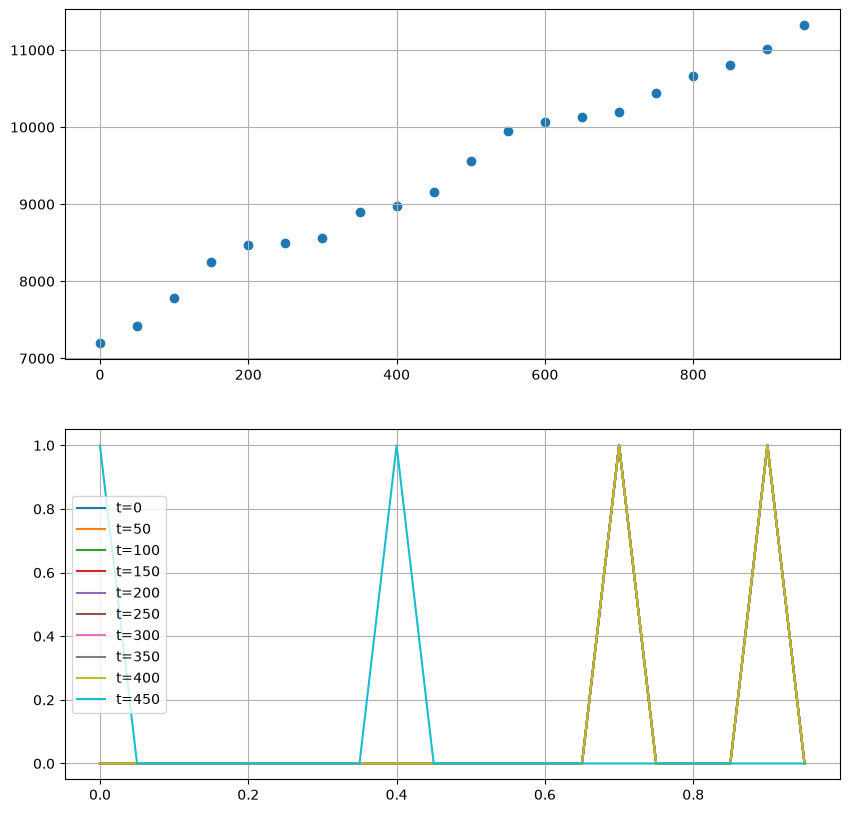

In [92]:
t = np.array([r[0] for r in results])
total_payoff = np.array([sum(r[1]) for r in results])
offers = np.array([r[2][0] for r in results])

fig, ax = plt.subplots(nrows=2, figsize=(10, 10))
ax[0].scatter(t, total_payoff)
for i, ps in enumerate(offers[::2]):
    counts, edges = np.histogram(ps, bins=20, range=(0.0, 1.0))
    ax[1].plot(edges[:-1], counts, label=f"t={t[i]}")

ax[0].grid()
ax[1].grid()
ax[1].legend()

plt.show()

TODO:
- Keep track of payoff/strategy/etc as numpy array instead of node attribute to improve performance
- Try to precompute certain metrics once (e.g. list of degrees, maybe adjacency matrix/neighbor lookup?)
- add writing results to files
- setup parameter space search

So what do we want to run:
- N = 5k nodes? what if I do only 1k?
- 100/1000 realizations per setting? (Initialisation, generated network,)
- 3 alpha settings x 3 player modes x 3 update strategy pairs x 20 ratios (I'm not doing this more fine-grained) -> 540 combinations? 
- for ~10k time steps? -> probably less sufficient (maybe figure out conditions for stopping sims dynamically when stationary state is reached)

... boy oh boy this needs to be faster